In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Shape: (300, 4)
       pengalaman     edu    gaji
count      300.00  300.00  300.00
mean         9.90    0.89   27.40
std          5.89    0.83   13.41
min          0.10    0.00    1.67
25%          4.78    0.00   16.24
50%         10.23    1.00   27.97
75%         15.14    2.00   38.89
max         19.80    2.00   54.22


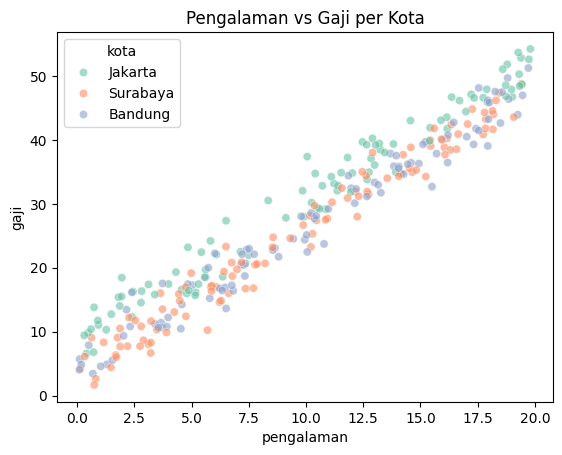

In [2]:
# Generate dataset sintetis
np.random.seed(42); n = 300
pengalaman = np.random.uniform(0, 20, n)
edu       = np.random.choice([0, 1, 2], n)   # SMA=0, D3=1, S1=2
kota      = np.random.choice(['Jakarta', 'Surabaya', 'Bandung'], n)
gaji = (3.0 + 2.2*pengalaman + 1.5*edu
        + np.where(kota=='Jakarta', 4.0, 0)
        + np.random.normal(0, 2, n))

df = pd.DataFrame({
    'pengalaman': pengalaman,
    'edu': edu,
    'kota': kota,
    'gaji': gaji
})

# EDA singkat
print('Shape:', df.shape)
print(df.describe().round(2))

# Scatter: pengalaman vs gaji
sns.scatterplot(
    data=df,
    x='pengalaman',
    y='gaji',
    hue='kota',
    palette='Set2',
    alpha=0.6
)

plt.title('Pengalaman vs Gaji per Kota')
plt.show()

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# One-Hot Encoding kolom 'kota'
df = pd.get_dummies(
    df,
    columns=['kota'],
    drop_first=True,
    dtype=int
)

print('Kolom setelah encoding:', df.columns.tolist())

# Pisahkan fitur dan target
X = df.drop('gaji', axis=1)
y = df['gaji']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(f'Train: {X_train.shape[0]} baris, Test: {X_test.shape[0]} baris')

# StandardScaler — fit pada training set saja
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

Kolom setelah encoding: ['pengalaman', 'edu', 'gaji', 'kota_Jakarta', 'kota_Surabaya']
Train: 240 baris, Test: 60 baris


In [4]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train_s, y_train)

# Tampilkan koefisien
print(f'β₀ (intercept): {model.intercept_:.3f}')
print()

coef_df = pd.DataFrame({
    'Fitur': X.columns,
    'Koefisien': model.coef_.round(3)
}).sort_values('Koefisien', ascending=False)

print(coef_df.to_string(index=False))

β₀ (intercept): 27.514

        Fitur  Koefisien
   pengalaman     13.042
 kota_Jakarta      1.837
          edu      1.188
kota_Surabaya     -0.292


In [6]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np

y_pred = model.predict(X_test_s)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print('=== Metrik Evaluasi ===')
print(f'MAE  = {mae:.3f} juta rupiah')
print(f'RMSE = {rmse:.3f} juta rupiah')
print(f'R²   = {r2:.4f} ({r2*100:.1f}% variasi dijelaskan)')
print(f'Selisih RMSE-MAE = {rmse-mae:.3f}')

=== Metrik Evaluasi ===
MAE  = 1.649 juta rupiah
RMSE = 2.123 juta rupiah
R²   = 0.9740 (97.4% variasi dijelaskan)
Selisih RMSE-MAE = 0.474


### 1. Berapa rata-rata kesalahan prediksi dalam rupiah?

Rata-rata kesalahan prediksi dapat dilihat dari **MAE (Mean Absolute Error)** sebesar **1,649 juta rupiah**. Artinya, secara rata-rata prediksi gaji yang dihasilkan model meleset sekitar **Rp 1.649.000** dari nilai gaji sebenarnya.

---

### 2. Apakah R² cukup baik untuk kasus ini?

Ya, **R² = 0,974** tergolong **sangat baik**. Nilai tersebut menunjukkan bahwa:
* Model mampu menjelaskan **97,4% variasi data gaji**.
* Hanya sekitar **2,6% variasi** yang tidak dapat dijelaskan oleh model.
* Hubungan antara fitur (pengalaman, pendidikan, dan kota) dengan target (gaji) berhasil dipelajari dengan sangat baik. Untuk dataset sintetis seperti ini, nilai R² sebesar 0,974 menunjukkan performa model yang sangat kuat.

---

### 3. Apakah ada indikasi outlier?

Tidak terdapat indikasi kuat adanya outlier, hal tersebut dikarenakan kedua hal berikut:
* **RMSE (2,123)** hanya sedikit lebih besar daripada **MAE (1,649)**.
* Selisih keduanya adalah **0,474 juta rupiah**, relatif kecil.
Karena RMSE memberikan penalti lebih besar terhadap error yang sangat besar, jika terdapat banyak outlier biasanya RMSE akan jauh lebih tinggi dibanding MAE.

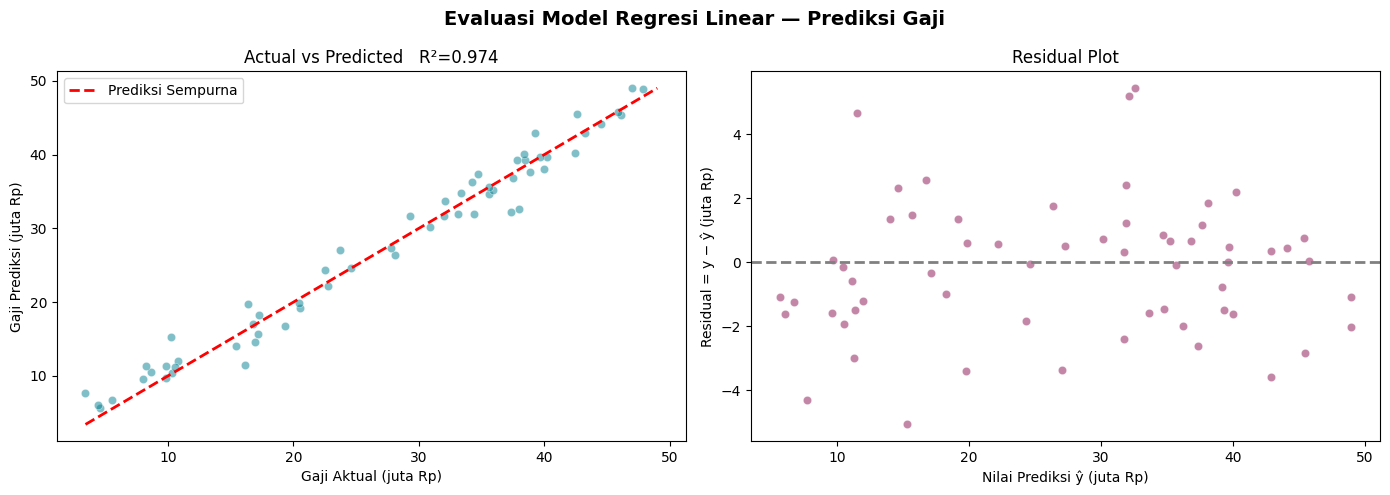

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Actual vs Predicted
axes[0].scatter(
    y_test,
    y_pred,
    alpha=0.5,
    color='#028090',
    edgecolors='white',
    lw=0.5
)

lims = [
    min(y_test.min(), y_pred.min()),
    max(y_test.max(), y_pred.max())
]

axes[0].plot(
    lims,
    lims,
    'r--',
    lw=2,
    label='Prediksi Sempurna'
)

axes[0].set_xlabel('Gaji Aktual (juta Rp)')
axes[0].set_ylabel('Gaji Prediksi (juta Rp)')
axes[0].set_title(f'Actual vs Predicted   R²={r2:.3f}')
axes[0].legend()

# Plot 2: Residual Plot
residuals = y_test - y_pred

axes[1].scatter(
    y_pred,
    residuals,
    alpha=0.5,
    color='#880E4F',
    edgecolors='white',
    lw=0.5
)

axes[1].axhline(
    0,
    color='gray',
    linestyle='--',
    lw=2
)

axes[1].set_xlabel('Nilai Prediksi ŷ (juta Rp)')
axes[1].set_ylabel('Residual = y − ŷ (juta Rp)')
axes[1].set_title('Residual Plot')

plt.suptitle(
    'Evaluasi Model Regresi Linear — Prediksi Gaji',
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout()
plt.savefig(
    'evaluasi_regresi.png',
    dpi=150,
    bbox_inches='tight'
)
plt.show()